## London Rental Insights: Predicting Prices and Identifying Affordable Neighborhoods

## Introduction

London (My home !), a vibrant and diverse city, is known for its dynamic housing market and unique rental challenges. For residents, understanding the factors influencing rental prices and identifying affordable areas within the city are critical for making informed decisions. However, navigating the rental market can be daunting due to fluctuating prices, varying neighborhood characteristics, and complex trade-offs between affordability, safety, and accessibility.

This project, aims to address these challenges by leveraging machine learning and data analysis. By combining predictive modeling with geospatial clustering, this study provides perspective on two fronts:

1. Rental Price Prediction: A machine learning model estimates rental prices based on property features and neighborhood attributes, offering transparency and aiding renters in gauging fair market prices.

2. Affordability Analysis: Clustering algorithms identify neighborhoods that provide the best rental value by considering commute times, safety, and proximity to amenities, helping renters discover areas that balance cost and quality of life.

To achieve these objectives, the project integrates data from diverse sources, including property listings, transportation networks, crime statistics, and geospatial data. **(edit if required). The outcome is a comprehensive analysis that not only predicts rental costs but also highlights affordability hotspots across London, delivering actionable insights for renters, landlords, and policymakers alike.

This project operates under limited resources and does not have access to comprehensive, real-time data specifically for properties. The dataset used can be considered as "notional data," representing a sample rather than an exhaustive or entirely accurate depiction of the rental market. Despite this, the project showcases the technical and analytical skills required to develop meaningful solutions. By demonstrating methodologies such as machine learning, clustering, and data visualization, it highlights potential approaches for building real-world applications using timely and accurate data in the future.

## Data

This dataset contains detailed information about rental properties across various locations in the UK. The data was collected by scraping Rightmove, a popular real estate platform. The dataset was created by Paritosh Sharma Ghimire. 

In [1]:
import pandas as pd
file_path = '/kaggle/input/london-property-rental/rent_ads_rightmove_extended.csv'
ldn_rent = pd.read_csv(file_path)
ldn_rent.head()

,address,subdistrict_code,rent,deposit,Let type,Furnish Type,Coucil Tax,PROPERTY TYPE,BEDROOMS,BATHROOMS,SIZE,avg_distance_to_nearest_station,nearest_station_count
0,"Morse Close, Harefield, UB9",UB9,1200,1384,Long term,Unfurnished,Ask agent,Apartment,1.0,1.0,Ask agent,2.1,3
1,"Dolphin Square, London, SW1V",SW1V,1983,2288,Long term,"Furnished or unfurnished, landlord is flexible",Ask agent,Apartment,1.0,1.0,335 sq ft,0.4,3
2,"Warlters Road, Holloway, London, N7",N7,1800,0,Long term,Unfurnished,Ask agent,Apartment,1.0,1.0,Ask agent,0.5,3
3,"Rockingham Road, Uxbridge",NaN,1650,1903,Long term,Unfurnished,Ask agent,Apartment,2.0,1.0,Ask agent,1.6,3
4,"Northwick Avenue, Harrow, HA3",HA3,2700,3115,Long term,Unfurnished,Ask agent,End of Terrace,3.0,2.0,Ask agent,0.4,3


## Data Definitions:
Address: The location of the property.

Subdistrict Code: Code representing the subdistrict of the property.

Rent: Monthly rental price for the property.

Deposit: Deposit amount required for the property.

Let Type: Indicates whether the property is available for short or long-term rental.

Furnish Type: Specifies if the property is furnished, unfurnished, or flexible in terms of furnishings.

Council Tax: Information about council tax for the property.

Property Type: Type of property such as apartment, flat, maisonette, etc.

Bedrooms: Number of bedrooms in the property.

Bathrooms: Number of bathrooms in the property.

Size: Size of the property in square feet.

Average Distance to Nearest Station: The average distance (in miles) to the nearest train station.

Nearest Station Count: Number of nearest train stations to the property.


As a quick note on data quality, The data contains missing values or "Ask agent" placeholders, which require direct inquiry with agents or landlords for specific information. 



# EDA

In [2]:
print("Dataset Info:")
print(ldn_rent.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3478 entries, 0 to 3477
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   address                          3478 non-null   object 
 1   subdistrict_code                 1868 non-null   object 
 2   rent                             3478 non-null   int64  
 3   deposit                          3478 non-null   int64  
 4   Let type                         3235 non-null   object 
 5   Furnish Type                     3477 non-null   object 
 6   Coucil Tax                       3477 non-null   object 
 7   PROPERTY TYPE                    3438 non-null   object 
 8   BEDROOMS                         2841 non-null   float64
 9   BATHROOMS                        3049 non-null   float64
 10  SIZE                             3478 non-null   object 
 11  avg_distance_to_nearest_station  3478 non-null   float64
 12  neares

In [3]:
# Checking for missing values
print("\nMissing Values:")
print(ldn_rent.isnull().sum())


Missing Values:
address                               0
subdistrict_code                   1610
rent                                  0
deposit                               0
Let type                            243
Furnish Type                          1
Coucil Tax                            1
PROPERTY TYPE                        40
BEDROOMS                            637
BATHROOMS                           429
SIZE                                  0
avg_distance_to_nearest_station       0
nearest_station_count                 0
dtype: int64


In [4]:
# Statistical summary of numerical columns
print("\nStatistical Summary:")
print(ldn_rent.describe())


Statistical Summary:
               rent       deposit     BEDROOMS    BATHROOMS  \
count   3478.000000   3478.000000  2841.000000  3049.000000   
mean    2593.092582   1789.097757     1.797958     1.431617   
std     2641.117440   2657.305000     0.916597     0.895819   
min       50.000000      0.000000     1.000000     1.000000   
25%     1550.000000      0.000000     1.000000     1.000000   
50%     2275.000000   1038.000000     2.000000     1.000000   
75%     3250.000000   2825.000000     2.000000     2.000000   
max    78000.000000  60000.000000     7.000000    20.000000   

       avg_distance_to_nearest_station  nearest_station_count  
count                      3478.000000            3478.000000  
mean                          0.494940               2.997412  
std                           0.361535               0.050811  
min                           0.100000               2.000000  
25%                           0.300000               3.000000  
50%                       

In [5]:
# Unique values for categorical columns
categorical_columns = ['subdistrict_code', 'Let type', 'Furnish Type', 'PROPERTY TYPE']
for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(ldn_rent[col].value_counts())


Unique values in subdistrict_code:
subdistrict_code
E14    202
SW5    178
SW7    173
W14     87
E16     56
      ... 
BR7      1
W1U      1
E6       1
BR2      1
UB9      1
Name: count, Length: 211, dtype: int64

Unique values in Let type:
Let type
Long term     3133
Short term     102
Name: count, dtype: int64

Unique values in Furnish Type:
Furnish Type
Furnished                                         1991
Unfurnished                                        526
Ask agent                                          423
Furnished or unfurnished, landlord is flexible     334
Part furnished                                     203
Name: count, dtype: int64

Unique values in PROPERTY TYPE:
PROPERTY TYPE
Flat                            1260
Apartment                       1035
House Share                      315
Studio                           258
Terraced                          86
Parking                           83
House                             79
Flat Share                        

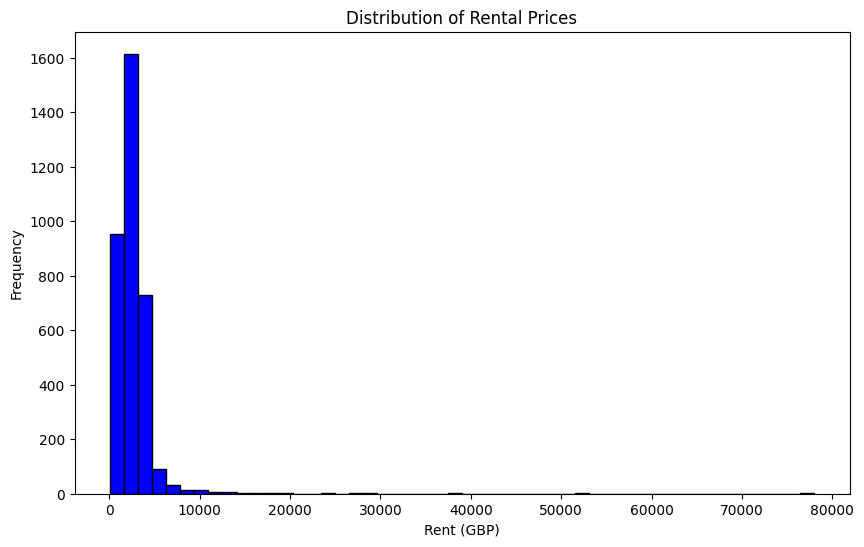

In [6]:
# Visualize the distribution of rental prices
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
ldn_rent['rent'].plot(kind='hist', bins=50, color='blue', edgecolor='black')
plt.title('Distribution of Rental Prices')
plt.xlabel('Rent (GBP)')
plt.ylabel('Frequency')
plt.show()

<Figure size 1200x800 with 0 Axes>

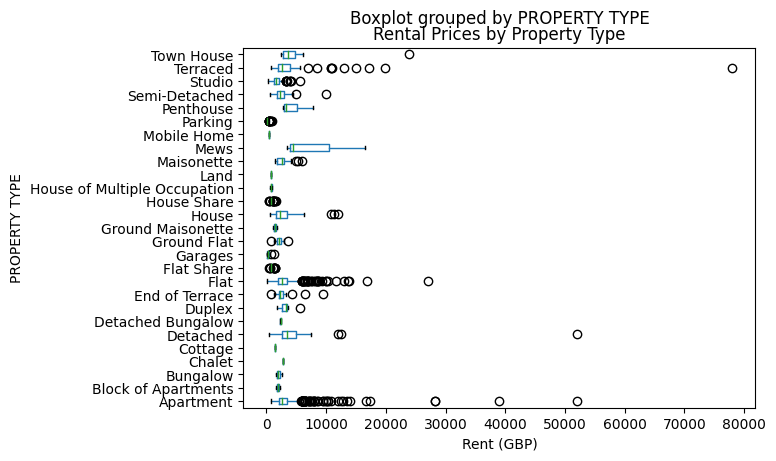

In [7]:
# Boxplot of rental prices grouped by property type
plt.figure(figsize=(12, 8))
ldn_rent.boxplot(column='rent', by='PROPERTY TYPE', grid=False, vert=False)
plt.title('Rental Prices by Property Type')
plt.xlabel('Rent (GBP)')
plt.show()

# INSIGHTS AND INFERENCES